In [50]:
import numpy as np
import matplotlib.pyplot as plt
from Basilisk.utilities import SimulationBaseClass, macros, orbitalMotion
from Basilisk.simulation import spacecraft, extForceTorque
from Basilisk.utilities import simIncludeGravBody
from Basilisk.architecture import messaging
from Basilisk.architecture import sysModel

In [57]:
# Simulation parameters
mu = 398600.0   # Earth's gravitational parameter (km^3/s^2)
R_E = 6378.0    # Earth radius (km)
alt_initial = 500.0       # initial orbit altitude (km)
alt_final   = 35000.0     # target orbit altitude (km)
R0 = R_E + alt_initial    # initial orbital radius (km)
Rf = R_E + alt_final      # target orbital radius (km)

stepSizeSec = 10.0   # or 5.0, 20.0, etc.
dynProcess = scSim.CreateNewProcess(simProcessName)
dynProcess.addTask(
    scSim.CreateNewTask(simTaskName, macros.sec2nano(stepSizeSec))
)

# Thrust and propulsion parameters
thrust = 1.0    # thrust (N)
Isp    = 10000.0  # specific impulse (s)
g0     = 9.81     # sea-level gravity (m/s^2)

In [58]:
# Create simulation
simTaskName    = "simTask"
simProcessName = "simProcess"
scSim = SimulationBaseClass.SimBaseClass()

# Set integration time step to 1 second
dynProcess = scSim.CreateNewProcess(simProcessName)
dynProcess.addTask(scSim.CreateNewTask(simTaskName, macros.sec2nano(30.0)))

# Create spacecraft object and set initial mass properties
scObject = spacecraft.Spacecraft()
scObject.ModelTag = "satellite"
scObject.hub.mHub = 1000.0                        # initial mass (kg)
scObject.hub.IHubPntBc_B = [[0.0]*3 for _ in range(3)]  # inertia matrix (not used in 3-DOF)
scObject.hub.r_BcB_B = [[0.0],[0.0],[0.0]]         # center of mass offset (zero)

# Initial orbital state (circular equatorial orbit at 500 km altitude)
scObject.hub.r_CN_NInit = [R0, 0.0, 0.0]                      # position vector (km)
scObject.hub.v_CN_NInit = [0.0, np.sqrt(mu/R0), 0.0]          # velocity vector (km/s)
scObject.hub.sigma_BNInit = [0.0, 0.0, 0.0]                   # attitude (MRPs, aligned with inertial)
scObject.hub.omega_BN_BInit = [0.0, 0.0, 0.0]                 # no rotation

# Configure Earth gravity model (central body)
gravFactory = simIncludeGravBody.gravBodyFactory()
earth = gravFactory.createEarth()
earth.isCentralBody = True
earth.mu = mu
gravFactory.addBodiesTo(scObject)   # attach Earth gravity to the spacecraft

# Create external force/torque effector for continuous thrust
extFTObject = extForceTorque.ExtForceTorque()
extFTObject.ModelTag = "continuousThrust"
extFTObject.extForce_N = [[0.0],[0.0],[0.0]]   # start with no thrust
scObject.addDynamicEffector(extFTObject)

In [59]:
# Define custom guidance module for low-thrust control
class LowThrustGuidance(sysModel.SysModel):
    def __init__(self, modelName, scObject, extFT, mu, targetRadius, stepSizeSec):
        # Basilisk SysModel init
        sysModel.SysModel.__init__(self)
        self.ModelTag = modelName

        # References
        self.scObject = scObject
        self.extFT    = extFT
        self.mu       = mu

        # Guidance params
        self.targetRadius = targetRadius
        self.active       = True
        self.cutoffTimeSec = 0.0

        # Time step (fixed)
        self.stepSizeSec = stepSizeSec

        # Propulsion
        # thrust, Isp, g0 must be defined globally just like in your script
        self.mass_flow = thrust / (Isp * g0)          # kg/s
        self.mass_flow_per_step = self.mass_flow * self.stepSizeSec

        # Spacecraft state input message
        self.scStateInMsg = messaging.SCStatesMsgReader()

    def Reset(self, currentTime):
        self.active = True
        self.cutoffTimeSec = 0.0

    def UpdateState(self, currentTime):
        # ---- 1) Read spacecraft state; bail out if not valid yet ----
        state = self.scStateInMsg()
        if state is None or len(state.r_BN_N) != 3 or len(state.v_BN_N) != 3:
            return

        r_BN_N = np.array(state.r_BN_N)
        v_BN_N = np.array(state.v_BN_N)

        r_mag = np.linalg.norm(r_BN_N)

        # ---- 2) Check cutoff condition ----
        if self.active and r_mag >= self.targetRadius:
            self.active = False
            self.cutoffTimeSec = currentTime * macros.NANO2SEC
            self.extFT.extForce_N = [[0.0],[0.0],[0.0]]
            return

        # ---- 3) If thrust active, set force and burn mass ----
        if self.active:
            v_mag = np.linalg.norm(v_BN_N)
            if v_mag > 1e-8:
                thrust_dir = v_BN_N / v_mag
            else:
                thrust_dir = np.zeros(3)

            # 1 N = 0.001 kg·km/s^2
            force_vec = 0.001 * thrust_dir
            self.extFT.extForce_B = force_vec

            # Mass update: fixed amount per step
            newMass = float(self.scObject.hub.mHub) - self.mass_flow_per_step
            self.scObject.hub.mHub = max(newMass, 0.0)

        else:
            # Thrust off
            self.extFT.extForce_N = [[0.0],[0.0],[0.0]]


In [60]:
# Instantiate guidance module and subscribe it to spacecraft state
guidanceModule = LowThrustGuidance(
    "lowThrustGuidance",
    scObject,
    extFTObject,
    mu,
    Rf,
    stepSizeSec
)
guidanceModule.scStateInMsg.subscribeTo(scObject.scStateOutMsg)

# Add components to simulation task with proper execution order
scSim.AddModelToTask(simTaskName, extFTObject, 2)      # then apply thrust force
scSim.AddModelToTask(simTaskName, guidanceModule, 1)   # guidance update first
scSim.AddModelToTask(simTaskName, scObject, 3)         # then propagate spacecraft dynamics

# Set up data logging for position, velocity, and mass
samplingTime = macros.sec2nano(1.0)
dataLog = scObject.scStateOutMsg.recorder(samplingTime)
massLog = scObject.scMassOutMsg.recorder(samplingTime)
scSim.AddModelToTask(simTaskName, dataLog, 4)
scSim.AddModelToTask(simTaskName, massLog, 5)

# Initialize and run simulation for thrust + coast duration (e.g. 80 days)
scSim.InitializeSimulation()
stopTime = macros.sec2nano(6912000.0)    # 6912000 s ~ 80 days
scSim.ConfigureStopTime(stopTime)
scSim.ExecuteSimulation()

# Retrieve logged results
posData = np.array(dataLog.r_BN_N)    # position time history (km)
velData = np.array(dataLog.v_BN_N)    # velocity time history (km/s)
timeAxis = dataLog.times() * macros.NANO2SEC    # time (s)
massData = np.array(massLog.massSC)   # mass time history (kg)

# Identify thrust cutoff index (when engine turned off)
if guidanceModule.cutoffTimeSec > 0:
    cutoff_idx = np.where(timeAxis >= guidanceModule.cutoffTimeSec)[0][0]
else:
    cutoff_idx = len(timeAxis) - int(14*24*3600) - 1  # (fallback, not expected)

# Compute initial and final orbit parameters
a_init = alt_initial
a_final = alt_final
v_init_val = np.sqrt(mu / R0)   # initial circular speed (km/s)
if guidanceModule.cutoffTimeSec == 0.0:
    print("WARNING: Thrust cutoff never occurred! Using end of simulation as fallback.")
    cutoff_idx = len(timeAxis) - 1
else:
    cutoff_idx = np.where(timeAxis >= guidanceModule.cutoffTimeSec)[0][0]
v_final_thrust = np.linalg.norm(velData[cutoff_idx-1])   # speed at thrust cutoff
v_final_coast  = np.linalg.norm(velData[-1])            # speed after coast period
prop_used = massData[0] - massData[cutoff_idx]          # propellant consumed (kg)
time_of_flight_days = guidanceModule.cutoffTimeSec / 86400.0   # flight time in days

# Final orbit after 14-day coast: measure eccentricity and radius error
pos_coast = posData[cutoff_idx:]
r_norms = np.linalg.norm(pos_coast, axis=1)
r_coast_apo = r_norms.max()     # final orbit apogee
r_coast_per = r_norms.min()     # final orbit perigee
r_coast_avg = 0.5 * (r_coast_per + r_coast_apo)
radius_error = (r_coast_avg - Rf) / Rf * 100.0        # percent radius error
e_coast = (r_coast_apo - r_coast_per) / (r_coast_apo + r_coast_per)   # eccentricity

In [61]:
print("Final radius achieved:", np.linalg.norm(posData[-1]))
print("Target radius:", Rf)
print("Difference:", Rf - np.linalg.norm(posData[-1]))


Final radius achieved: nan
Target radius: 41378.0
Difference: nan


Initial Altitude: 500.0 km
Final Target Altitude: 35000.0 km
Max Thrust: 1.0 N
Initial speed: 7.613 km/s
Final (thrust cutoff) speed: nan km/s
23.4861 kg of propellant used
Time of flight: 0.0000 days
Coast Radius Percent Error: nan %
Final orbit eccentricity: nan
Speed after coast: nan km/s


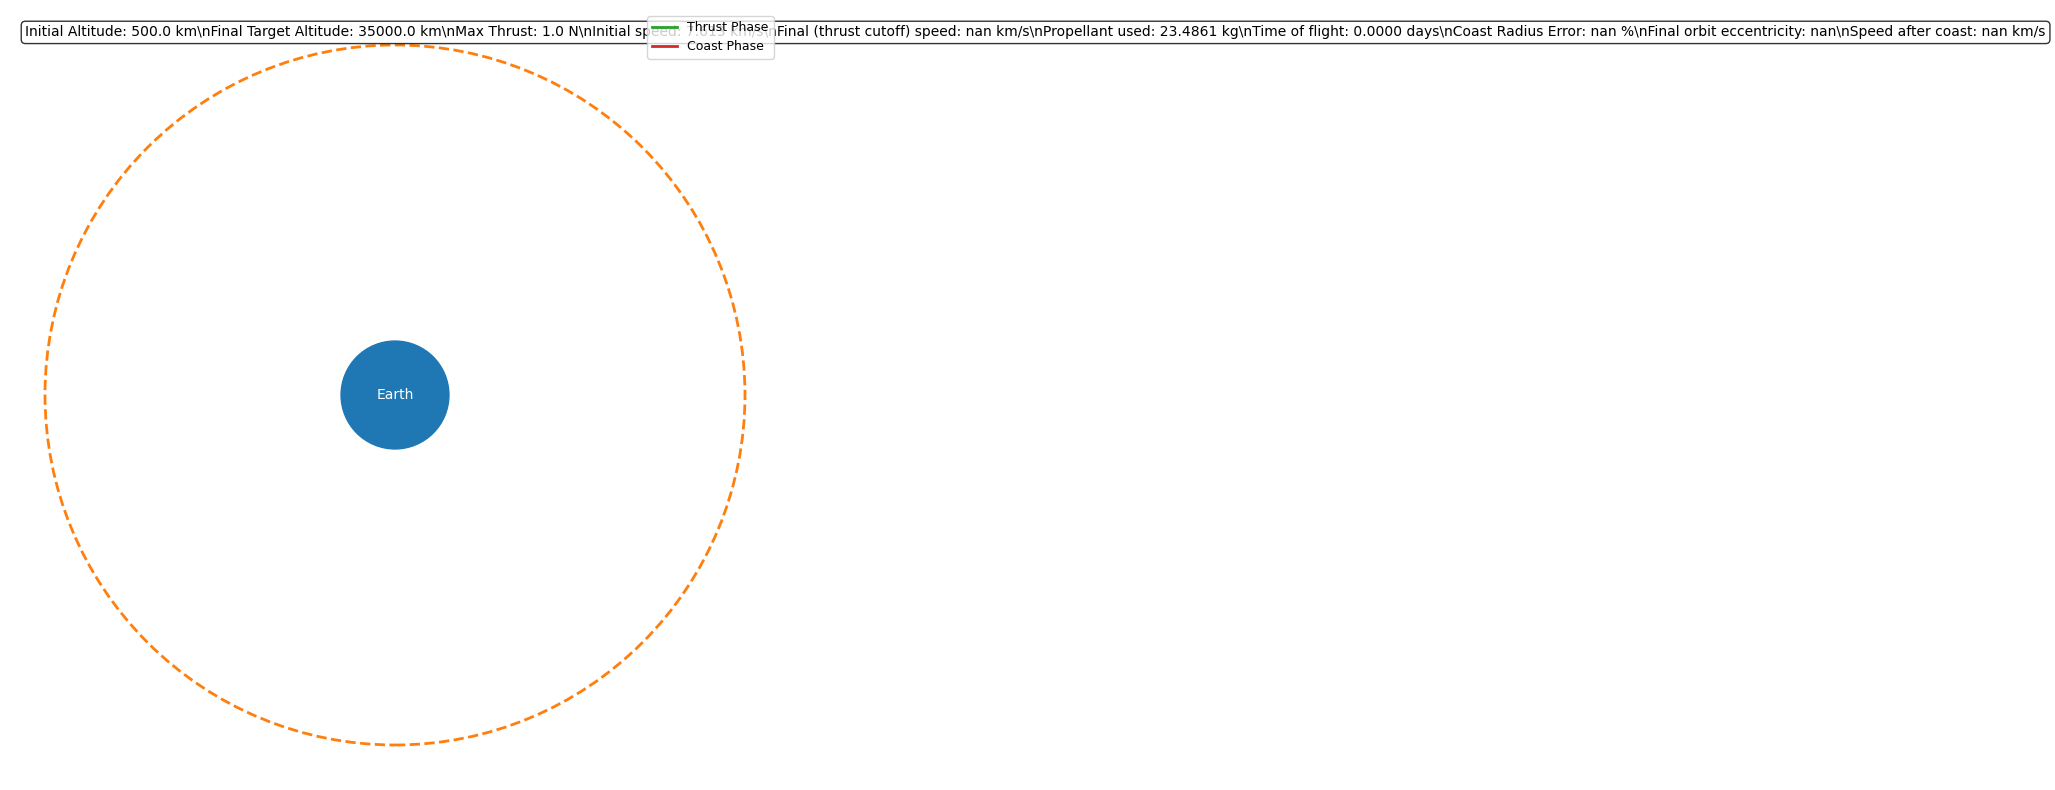

In [62]:
# Print mission summary report
print(f"Initial Altitude: {a_init} km")
print(f"Final Target Altitude: {a_final} km")
print(f"Max Thrust: {thrust:.1f} N")
print(f"Initial speed: {v_init_val:.3f} km/s")
print(f"Final (thrust cutoff) speed: {v_final_thrust:.3f} km/s")
print(f"{prop_used:.4f} kg of propellant used")
print(f"Time of flight: {time_of_flight_days:.4f} days")
print(f"Coast Radius Percent Error: {radius_error:.3f} %")
print(f"Final orbit eccentricity: {e_coast:.5f}")
print(f"Speed after coast: {v_final_coast:.3f} km/s")

# Plot Earth, target orbit, and trajectory
plt.figure(figsize=(10,10))
ax = plt.gca()
ax.set_aspect('equal', 'box')
ax.axis('off')
# Earth (filled circle)
earth_patch = plt.Circle((0,0), R_E, color='C0')
ax.add_patch(earth_patch)
ax.annotate("Earth", (0,0), ha='center', va='center', color='w')
# Target orbit radius (dashed circle)
target_patch = plt.Circle((0,0), Rf, fill=False, color='C1', ls='--', lw=2)
ax.add_patch(target_patch)
# Trajectory: thrust phase and coast phase
pos_thrust = posData[:cutoff_idx]
pos_coast  = posData[cutoff_idx:]
ax.plot(pos_thrust[:,0], pos_thrust[:,1], color='C2', lw=2, label='Thrust Phase')
ax.plot(pos_coast[:,0],  pos_coast[:,1],  color='C3', lw=2, label='Coast Phase')
ax.legend(loc='upper right')
# Annotate summary on plot
summary_text = (
    f"Initial Altitude: {a_init} km\\n"
    f"Final Target Altitude: {a_final} km\\n"
    f"Max Thrust: {thrust:.1f} N\\n"
    f"Initial speed: {v_init_val:.3f} km/s\\n"
    f"Final (thrust cutoff) speed: {v_final_thrust:.3f} km/s\\n"
    f"Propellant used: {prop_used:.4f} kg\\n"
    f"Time of flight: {time_of_flight_days:.4f} days\\n"
    f"Coast Radius Error: {radius_error:.3f} %\\n"
    f"Final orbit eccentricity: {e_coast:.5f}\\n"
    f"Speed after coast: {v_final_coast:.3f} km/s"
)
ax.text(0.02, 0.98, summary_text, transform=ax.transAxes, fontsize=10,
        va='top', ha='left',
        bbox=dict(boxstyle="round", fc="white", alpha=0.8))
plt.show()